In [1]:
import torch
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Build Environment

In [2]:
size = 3
states = size * size
rewards = torch.tensor([1,0])
n_rewards = 2
num_actions = 4

In [3]:
def step_function(state, action):
    row, col = state // size, state % size

    action_names = ['up', 'down', 'left', 'right']

    action_move = [
        lambda row, col: (max(0, row-1), col),      # up
        lambda row, col: (min(size-1, row+1), col),  # down
        lambda row, col: (row, max(col-1, 0)),       # left
        lambda row, col: (row, min(col+1, size-1))   # right
    ]

    new_row, new_col = action_move[action](row, col)
    new_state = new_row * size + new_col

    # print(f"Action: {action_names[action]}")

    return new_state
# state, state_col, state_row = step_function(4,3)

def policy_improvement(Q, epsilon = 0.1):
    num_states, num_actions = Q.shape
    new_policy = torch.zeros(num_states, num_actions)

    for s in range(num_states):
        best_action = Q[s].argmax(0).item()

        for a in range(num_actions):
            if a == best_action:
                new_policy[s, a] = 1.0 - epsilon + (epsilon / num_actions)
            else:
                new_policy[s, a] = epsilon / num_actions
    return new_policy

# Dyna-Q

In [4]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [8]
V = torch.zeros(states)
Q = torch.zeros(states, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.6

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards



Model_next_state = torch.full((states, num_actions), -1)
Model_reward     = torch.zeros(states, num_actions)
experienced = []
planning_steps = 10
epsilon=0.9


counter = 0

planning...:   0%|          | 0/10 [00:00<?, ?it/s]

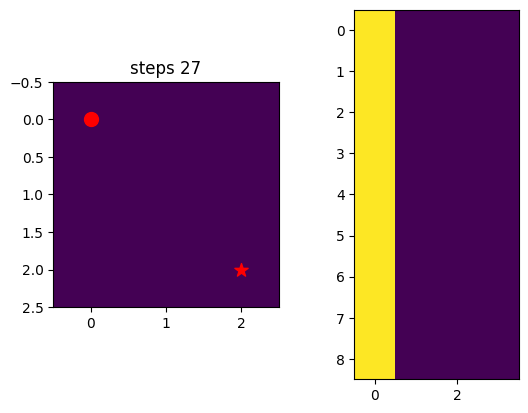

In [31]:
# ONE STEPPING Dyna-Q

action = torch.multinomial(policy[state], 1)
old_state  = state
old_action = action.item()

current_state = old_state  # for visualization

if (old_state, old_action) not in experienced:
    experienced.append((old_state, old_action))


new_state = step_function(old_state, old_action)
reward = rewards[new_state].item()


if new_state in terminal_states:
    Q[old_state, old_action] += alpha * (reward - Q[old_state, old_action])
    state = initial_state
    counter = 0
else:
    Q[old_state, old_action] += alpha * (reward + discount_factor * Q[new_state].max() - Q[old_state, old_action])
    state = new_state
    counter +=1

action = torch.multinomial(policy[state], 1)

# update the model with the real experience
Model_next_state[old_state, old_action] = new_state
Model_reward[old_state, old_action]     = reward

# sample random state actions from the state and actions we observed in real world.
# update the q values wrt these imaginary movements.
for _ in tqdm(range(planning_steps), desc= "planning..."):
    s_p, a_p = random.choice(experienced)
    s_model = int(Model_next_state[s_p, a_p].item())
    r_model = float(Model_reward[s_p, a_p].item())
    if s_model in terminal_states:
        Q[s_p, a_p] += alpha * (r_model - Q[s_p, a_p])
    else:
        Q[s_p, a_p] += alpha * (r_model + discount_factor * Q[s_model].max() - Q[s_p, a_p])

epsilon=0.1 # set this high at the beginning.
policy = policy_improvement(Q, epsilon)

# ----------- VIZ ---------------
fig, ax = plt.subplots(1, 2)

current_row = current_state // size
current_col = current_state % size
ax[0].scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
    ts_row = ts // size
    ts_col = ts % size
    ax[0].scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size

ax[0].annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = Q.max(dim=1)[0].view(size, size)

ax[0].imshow(V_grid)
ax[0].set_title(f"steps {counter}")
ax[1].imshow(policy)
plt.show()


# continue running till the agent arrives at the terminal state

# Exploration exploitation trade off

---


## **during real experience**
one problem that i found is that i find it difficult to balance the trade off between esploration and esploitation, in particular at the beginning. as we saw in chapter 1 with bandits we have several alternatives to balance it:
- Decay epsilon over time: Start high (0.5 or even 1.0), decay it gradually as learning progresses. This way you explore heavily early, then exploit later.
- Use a different exploration strategy: Upper Confidence Bound (UCB) or Boltzmann exploration adapt automatically without manual tuning. They prioritize actions you haven't tried much, which is smarter than random exploration.
- Initialize Q-values optimistically: Instead of all zeros, initialize Q-values high. Then suboptimal actions naturally get lower estimates first, and you naturally explore more.
- Increase planning steps: In Dyna, if you do more planning early on, you can learn the model faster and explore more efficiently through imagination rather than pure epsilon-greedy.



---


## **during planning steps**
if we want to explore more during planning steps we can use Dyna-Q+
